<a href="https://colab.research.google.com/github/FelipeCaves/DeepLearningDuocSB/blob/main/EV01_DL_fase_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1: Carga y Preprocesamiento de Datos

## Descripción y Justificación de Decisiones Técnicas

Para el desarrollo de este modelo Perceptrón Multicapa (MLP) enfocado en la clasificación de imágenes (Paltas vs. Otras Frutas), se ha diseñado un pipeline de ingesta y preprocesamiento de datos basado en las siguientes decisiones técnicas:

1. **Carga Autónoma y Reproducible:** Los datos se ingestan directamente desde un repositorio público en la nube mediante `gdown`. **Justificación:** Esto elimina la dependencia de rutas locales o permisos privados, garantizando que el entorno sea 100% reproducible por cualquier evaluador.
2. **Redimensionamiento (Resizing):** Todas las imágenes se estandarizan a una resolución de 64x64 píxeles. **Justificación:** A diferencia de las redes convolucionales (CNN), un MLP requiere aplanar la imagen en un vector 1D. Imágenes muy grandes generarían una explosión combinatoria de pesos en las capas densas, ralentizando el entrenamiento y aumentando el riesgo de *overfitting*.
3. **Partición Estricta (80% - 10% - 10%):** La partición se realiza sobre el total de imágenes (228). Se reconoce que este es un dataset pequeño, lo que puede generar variabilidad en las métricas finales. Para mitigar esto, se fija una semilla (seed=42) garantizando reproducibilidad. **Justificación:** Validar y probar con el mismo set sesga las métricas. Aislar un Test Set garantiza una evaluación sobre datos completamente invisibles para la red durante su entrenamiento.
4. **Normalización de Escala:** Se aplicó una capa `Rescaling(1./255)`. **Justificación:** Escalar los valores de los píxeles del rango [0, 255] al rango [0.0, 1.0] asegura que las variables de entrada tengan una magnitud similar, lo que estabiliza matemáticamente el descenso del gradiente y permite una convergencia más rápida del algoritmo.
5. **Optimización del Flujo de Datos (AUTOTUNE):** Se implementó paralelización asíncrona mediante `.map()` y `.prefetch(AUTOTUNE)`. **Justificación:** Esto evita cuellos de botella en el hardware. Mientras el modelo entrena un lote, el sistema ya está procesando y normalizando el siguiente en la memoria caché, maximizando la eficiencia computacional.
6. **Visualización de ejemplos:** Se muestran muestras representativas del dataset ya normalizado para verificar visualmente que el preprocesamiento fue aplicado correctamente. **Justificación** La verificación visual permite detectar errores en la carga (imágenes corruptas, etiquetas cruzadas) y confirmar empíricamente que la normalización redujo los valores al rango [0,1], lo cual es requisito para una convergencia estable del gradiente.

In [2]:
import os
import tensorflow as tf
from tensorflow.keras import layers

# 1. DESCARGA DEL ARCHIVO .ZIP PÚBLICO
id_zip = '1L66JVpBghD_9t2E9jHCHTqcM55N7M6Ho'

!gdown --id {id_zip} -O dataset.zip
!unzip -o -q dataset.zip -d dataset_extraido


# 2. PARÁMETROS BASE Y RUTAS
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

ruta_dataset = 'dataset_extraido/dataset_ev01'


# 3. LECTURA Y DIVISIÓN MATEMÁTICA (80% - 10% - 10%)
print("\n--- Iniciando partición del dataset ---")

dataset_entrenamiento = tf.keras.utils.image_dataset_from_directory(
    ruta_dataset,
    validation_split=0.2,   # 20% para validación + prueba
    subset="training",       # 80% entrenamiento
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

dataset_val_test = tf.keras.utils.image_dataset_from_directory(
    ruta_dataset,
    validation_split=0.2,
    subset="validation",     # Subset 20% restante
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Dividir el 20% restante en mitades iguales → 10% val, 10% test
mitad = len(dataset_val_test) // 2
dataset_validacion = dataset_val_test.take(mitad)
dataset_prueba     = dataset_val_test.skip(mitad)

nombres_clases = dataset_entrenamiento.class_names
print(f"Clases detectadas: {nombres_clases}")
print(f"Lotes entrenamiento: {len(dataset_entrenamiento)} | "
      f"Validación: {len(dataset_validacion)} | "
      f"Prueba: {len(dataset_prueba)}")


# 4. NORMALIZACIÓN Y OPTIMIZACIÓN DE MEMORIA (PREFETCH)
print("--- Aplicando normalización y optimización asíncrona ---")

capa_normalizacion = layers.Rescaling(1./255)

# Se agrega tf.cast para garantizar que los tensores sean float32
# antes del Rescaling, evitando que los valores queden en rango [0,255]
def normalizar(imagen, etiqueta):
    imagen = tf.cast(imagen, tf.float32)
    return capa_normalizacion(imagen), etiqueta

dataset_entrenamiento = dataset_entrenamiento.map(normalizar, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
dataset_validacion    = dataset_validacion.map(normalizar, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
dataset_prueba        = dataset_prueba.map(normalizar, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

print("\nlisto! a entrenar la red neuronal.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1L66JVpBghD_9t2E9jHCHTqcM55N7M6Ho
To: /content/dataset.zip
100% 2.09M/2.09M [00:00<00:00, 226MB/s]

--- Iniciando partición del dataset ---
Found 228 files belonging to 2 classes.
Using 183 files for training.
Found 228 files belonging to 2 classes.
Using 45 files for validation.
Clases detectadas: ['otras_frutas', 'paltas']
Lotes entrenamiento: 6 | Validación: 1 | Prueba: 1
--- Aplicando normalización y optimización asíncrona ---

listo! a entrenar la red neuronal.


In [3]:
import os
print(os.listdir())

['.config', 'dataset_extraido', 'dataset.zip', 'sample_data']


- Verificación visual del preprocesamiento -


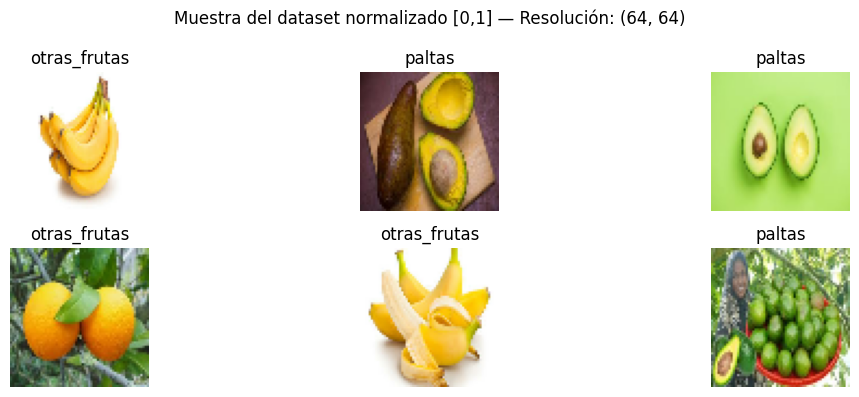


Valor mínimo de píxel: 0.0000
Valor máximo de píxel: 1.0000
Normalización correcta: valores en rango [0, 1]


In [4]:
# 5. VISUALIZACIÓN DE EJEMPLOS DEL DATASET NORMALIZADO
import matplotlib.pyplot as plt

print("- Verificación visual del preprocesamiento -")

for imagenes, etiquetas in dataset_entrenamiento.take(1):
    plt.figure(figsize=(12, 4))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(imagenes[i].numpy())
        plt.title(nombres_clases[etiquetas[i].numpy()])
        plt.axis('off')
    plt.suptitle(
        f"Muestra del dataset normalizado [0,1] — Resolución: {IMG_SIZE}",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

# Verificación de rango de valores
print(f"\nValor mínimo de píxel: {imagenes[0].numpy().min():.4f}")
print(f"Valor máximo de píxel: {imagenes[0].numpy().max():.4f}")
print("Normalización correcta: valores en rango [0, 1]")

# Fase 2: Definición del Modelo MLP

1.   Elemento de la lista
2.   Elemento de la lista



## Descripción y Justificación de Decisiones Técnicas

1. **Arquitectura Secuencial:** Se implementa tf.keras.Sequential con capas Flatten → Dense(256, relu) → Dropout(0.4) → Dense(128, relu) → Dropout(0.3) → Dense(1, sigmoid). **Justificación:** El aplanamiento permite adaptar imágenes (64×64×3) a un formato 1D requerido por MLPs, mientras que las capas densas extraen patrones no lineales. Dropout reduce el riesgo de overfitting en un dataset pequeño.
2. **Funciones de Activación (ReLU):** Se utiliza ReLU en capas ocultas. **Justificación:** Introduce no linealidad sin saturar gradientes en valores positivos, permitiendo una convergencia más rápida y estable frente a funciones como Sigmoid en capas internas.
3. **Función de Salida (Sigmoid):** Se emplea Sigmoid en la capa final. **Justificación:** Convierte la salida en una probabilidad en el rango (0,1), adecuada para clasificación binaria (palta vs. no palta).
4. **Función de Pérdida (Binary Crossentropy):** Se utiliza entropía cruzada binaria. **Justificación:** Penaliza con mayor fuerza errores de alta confianza y proporciona gradientes más informativos que alternativas como MSE en problemas de clasificación binaria.
5. **Regularización (Dropout):** Se aplican tasas de 0.4 y 0.3 en capas ocultas. **Justificación:** Fuerza al modelo a aprender representaciones más generales, reduciendo la memorización de datos debido al tamaño limitado del dataset (228 imágenes).
6. **Optimizador (Adam):** Se utiliza Adam como algoritmo de optimización. **Justificación:** Ajusta dinámicamente la tasa de aprendizaje por parámetro, combinando eficiencia y estabilidad, lo que lo hace una elección robusta para este tipo de problemas.

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

# DEFINICIÓN DEL MODELO MLP
def construir_modelo(activacion='relu', learning_rate=0.001, dropout=True):
    """
    Construye un MLP para clasificación binaria de imágenes 64x64x3.
    Parámetros:
      activacion    : Función de activación de las capas ocultas
      learning_rate : Tasa de aprendizaje del optimizador Adam
      dropout       : IF True, aplica Dropout para regularización
    """
    modelo = models.Sequential([
        tf.keras.Input(shape=(64, 64, 3)), # Define the input shape explicitly
        # Aplanar imagen 64x64x3 → vector de 12.288 valores
        layers.Flatten(),

        # Primera capa oculta con ReLU
        layers.Dense(256, activation=activacion),
        layers.Dropout(0.4) if dropout else layers.Lambda(lambda x: x),

        # Segunda capa oculta con ReLU
        layers.Dense(128, activation=activacion),
        layers.Dropout(0.3) if dropout else layers.Lambda(lambda x: x),

        # Capa de salida: Sigmoid → probabilidad binaria
        layers.Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',  # función de error para clasificación binaria
        metrics=['accuracy']
    )
    return modelo

# Mostrar arquitectura
modelo = construir_modelo()
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,179,009 (12.13 MB)

 Trainable params: 3,179,009 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

# Fase 3: Entrenamiento y Experimentación del Modelo
## Entrenamiento del Modelo
En esta sección se entrena el modelo utilizando los datos previamente procesados.
El objetivo es que la red neuronal aprenda a diferenciar entre imágenes de paltas y no paltas.

Se utilizan parámetros como:
- Número de épocas (epochs)
- Tamaño de batch (batch size)

Estos parámetros influyen directamente en el rendimiento del modelo.

In [27]:
history = modelo.fit(
    dataset_entrenamiento,
    epochs=10,
    validation_data=dataset_validacion
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - accuracy: 0.6011 - loss: 2.6587 - val_accuracy: 0.4688 - val_loss: 3.0957
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5738 - loss: 3.0375 - val_accuracy: 0.4688 - val_loss: 3.0158
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5792 - loss: 3.0176 - val_accuracy: 0.5312 - val_loss: 0.8598
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5301 - loss: 2.4989 - val_accuracy: 0.4688 - val_loss: 1.0246
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5082 - loss: 1.7084 - val_accuracy: 0.4688 - val_loss: 0.7935
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5410 - loss: 1.5156 - val_accuracy: 0.5000 - val_loss: 0.7822
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5902 - loss: 1.2679 - val_accuracy: 0.6562 - val_loss: 0.6142
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5410 - loss: 0.9145 - val_accuracy: 0.5938 - val_loss: 0.6457
Epoch 

# El entrenamiento se realiza durante 10 épocas, lo que permite al modelo iterar varias veces sobre los datos y mejorar su precisión.

## Visualización del Entrenamiento

Se grafica la precisión (accuracy) del modelo durante el entrenamiento y validación para analizar su comportamiento.

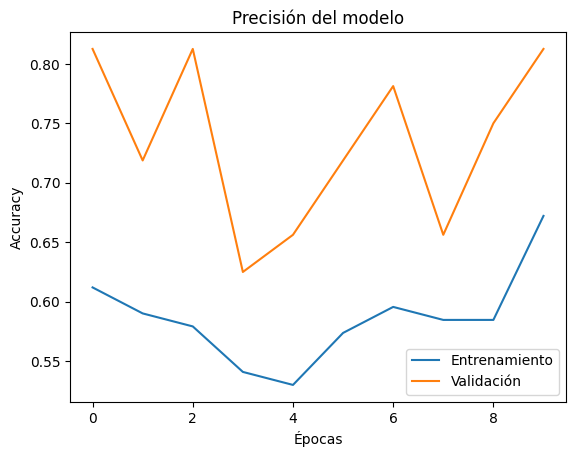

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Se observa que la precisión del entrenamiento aumenta progresivamente, mientras que la validación permite verificar si el modelo generaliza correctamente.

Si la precisión de entrenamiento es mucho mayor que la de validación, puede existir overfitting.

## Experimento 1: Variación del número de épocas

Se entrena el modelo con diferentes cantidades de épocas para analizar cómo influye en la precisión.

In [23]:
# IMPORTANTE: recrear modelo antes de cada entrenamiento
model_1 = construir_modelo()
history_5 = model_1.fit(dataset_entrenamiento, epochs=5, batch_size=32, validation_data=dataset_validacion)

model_2 = construir_modelo()
history_20 = model_2.fit(dataset_entrenamiento, epochs=20, batch_size=32, validation_data=dataset_validacion)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - accuracy: 0.5519 - loss: 2.4344 - val_accuracy: 0.4688 - val_loss: 2.0758
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5574 - loss: 3.3797 - val_accuracy: 0.4688 - val_loss: 2.4535
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5574 - loss: 3.0777 - val_accuracy: 0.4688 - val_loss: 2.2780
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4645 - loss: 3.1002 - val_accuracy: 0.5312 - val_loss: 0.6366
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5574 - loss: 1.8557 - val_accuracy: 0.4688 - val_loss: 1.3531
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 431ms/step - accuracy: 0.5464 - loss: 2.8801 - val_accuracy: 0.4688 - val_loss: 3.1008
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4918 - loss: 2.5915 - val_accuracy: 0.5312 - val_loss: 0.9304
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5847 - loss: 1.5404 - val_accuracy: 0.6562 - val_loss: 0.6315
Epoch 4/2

## Experimento 2: Variación del batch size

Se analiza cómo el tamaño del batch afecta el proceso de entrenamiento del modelo.

In [25]:
model_3 = construir_modelo()
history_16 = model_3.fit(dataset_entrenamiento, epochs=10, batch_size=16, validation_data=dataset_validacion)

model_4 = construir_modelo()
history_64 = model_4.fit(dataset_entrenamiento, epochs=10, batch_size=64, validation_data=dataset_validacion)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step - accuracy: 0.5027 - loss: 2.5568 - val_accuracy: 0.5312 - val_loss: 0.6860
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5410 - loss: 2.6356 - val_accuracy: 0.4688 - val_loss: 1.5261
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5082 - loss: 2.4170 - val_accuracy: 0.5312 - val_loss: 0.8382
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5902 - loss: 1.5154 - val_accuracy: 0.4688 - val_loss: 0.8561
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5628 - loss: 1.6640 - val_accuracy: 0.4688 - val_loss: 1.0124
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4973 - loss: 1.3143 - val_accuracy: 0.4688 - val_loss: 0.7781
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5792 - loss: 1.0344 - val_accuracy: 0.6250 - val_loss: 0.6371
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6557 - loss: 0.7599 - val_accuracy: 0.5312 - val_loss: 0.6817
Epoch 

## Comparación de Resultados

Se comparan los resultados obtenidos con distintas configuraciones de entrenamiento.

In [28]:
import pandas as pd

resultados = pd.DataFrame({
    "Configuración": ["Epochs=5", "Epochs=10", "Epochs=20", "Batch=16", "Batch=64"],
    "Accuracy": [
        history_5.history['val_accuracy'][-1],
        history.history['val_accuracy'][-1],
        history_20.history['val_accuracy'][-1],
        history_16.history['val_accuracy'][-1],
        history_64.history['val_accuracy'][-1]
    ]
})

resultados

,Configuración,Accuracy
0,Epochs=5,0.46875
1,Epochs=10,0.59375
2,Epochs=20,0.59375
3,Batch=16,0.78125
4,Batch=64,0.65625


## Análisis de Resultados

Se observa que al aumentar el número de épocas, el modelo mejora su precisión inicial, ya que logra aprender mejor las características de las imágenes.

Sin embargo, un número excesivo de épocas puede provocar overfitting, lo que significa que el modelo se ajusta demasiado a los datos de entrenamiento y pierde capacidad de generalización.

Respecto al batch size, valores pequeños permiten un aprendizaje más detallado pero más lento, mientras que valores grandes hacen el entrenamiento más rápido, pero pueden reducir la precisión.

Por lo tanto, es importante encontrar un equilibrio en estos hiperparámetros para obtener un modelo eficiente y con buen rendimiento.